# nb27 — Router v2: cross-band inverse-variance pooling of astrometry

nb25/nb26 established on injections that per-band position errors are independent, that
informations add ($3.40$ mas from ten bands vs $7.98$ VIS-only at peak SNR 10), and that
realistic SEDs offer a ×1.47 median error-shrink over VIS-only. The production correction
does not exploit this: the head reads only the fused bottleneck + VIS stem, and the nb24
sigma router combines head-vs-classical **within** each band. The published bright-star
Gaia number (5.4 mas) does pool across bands — but with an **unweighted median over Rubin
bands only**.

Router v2 changes only the final aggregation: pool the per-band router positions with
**calibrated inverse-variance weights** (per-measurement $\sigma$ from the router's own
$\sigma_{\rm cl}$, $\alpha$-calibrated $\sigma_h$, and $\rho$), optionally including NISP.
Zero retraining; pure catalog-level change.

Lessons from nb25/26 baked in: (1) weights use *calibrated* $\sigma$'s (the head is
over-confident by $\alpha\approx2$ on bright stars — uncalibrated weights would repeat the
shrinkage-bias failure); (2) pooling only helps to the extent per-band errors are
independent **on real sky** — the inter-band error-correlation matrix vs Gaia is measured
below, and it (not the injection ideal) sets the collectible gain; (3) the head component
of the router position pulls every band toward the same canonical position, so a shared
error component is expected — quantified, not assumed.

Everything below runs on the nb24 anchors archive (ECDFS, test half = tiles not used for
calibration), rebuilt with nb24's own cells.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from astropy.io import fits

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root()
OUT=REPO/'io/_nb24_outputs'; OUT.mkdir(exist_ok=True)
ARCH=REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_sigma.npz'
d=np.load(ARCH,allow_pickle=True)
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']; RUBIN=['u','g','r','i','z','y']
cosd=np.cos(np.deg2rad(np.median(np.asarray(d['i_dec'],float))))
rng=np.random.default_rng(42)

def cluster(xy,r):
    t=cKDTree(xy); pairs=t.query_pairs(r,output_type='ndarray')
    par=np.arange(len(xy))
    def f(a):
        while par[a]!=a: par[a]=par[par[a]]; a=par[a]
        return a
    for a,b in pairs:
        x,y=f(a),f(b)
        if x!=y: par[x]=y
    lab=np.array([f(i) for i in range(len(xy))]); _,lab=np.unique(lab,return_inverse=True); return lab

ent=[]
for b in BANDS:
    ra=np.asarray(d[f'{b}_ra'],float); dec=np.asarray(d[f'{b}_dec'],float)
    raw=np.asarray(d[f'{b}_raw'],float)*1000.; res=np.asarray(d[f'{b}_head_resid'],float)*1000.
    snr=np.asarray(d[f'{b}_snr'],float); sig=np.asarray(d[f'{b}_sigma'],float)*1000.
    tl=np.asarray(d[f'{b}_tiles'])
    ok=np.isfinite(raw).all(1)&np.isfinite(res).all(1)&np.isfinite(snr)&(snr>0)&np.isfinite(sig)&(sig>0)
    lab=cluster(np.column_stack([ra[ok]*cosd*3600,dec[ok]*3600]),0.3)
    df=pd.DataFrame(dict(g=lab,ra=ra[ok],dec=dec[ok],rx=raw[ok,0],ry=raw[ok,1],
                         ex=res[ok,0],ey=res[ok,1],snr=snr[ok],sig=sig[ok],tile=tl[ok]))
    a=df.groupby('g').agg(ra=('ra','median'),dec=('dec','median'),rx=('rx','median'),ry=('ry','median'),
        ex=('ex','median'),ey=('ey','median'),snr=('snr','median'),sig=('sig','median'),
        tile=('tile','first')).reset_index(drop=True)
    a['band']=b; ent.append(a)
long=pd.concat(ent,ignore_index=True)
long['src']=cluster(np.column_stack([long.ra*cosd*3600,long.dec*3600]),0.4)
long=long.sort_values('snr',ascending=False).drop_duplicates(['src','band']).reset_index(drop=True)
long['raw']=np.hypot(long.rx,long.ry); long['res']=np.hypot(long.ex,long.ey)
import hashlib
long['calib']=long.tile.map(lambda t: int(hashlib.md5(str(t).encode()).hexdigest(),16)%2==0)  # deterministic tile split
print(f'{len(long):,} measurements, {long.src.nunique():,} sources; '
      f'calibration half {long.calib.mean():.0%} of measurements')

pos=long.groupby('src')[['ra','dec']].median()
hs=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_q1_ECDFS_Hsize.fits')[1].data
mc=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits')[1].data
def attach(cra,cdec,vals,rad=0.5):
    t=cKDTree(np.column_stack([np.asarray(cra,float)*cosd,np.asarray(cdec,float)]))
    dist,idx=t.query(np.column_stack([pos.ra*cosd,pos.dec]),k=1)
    return np.where(dist*3600<rad,np.asarray(vals,float)[idx],np.nan)
pos['plike']=attach(hs['ra'],hs['dec'],hs['point_like_prob'])
pos['vmag']=attach(mc['ra'],mc['dec'],mc['mag_vis'])
gaia=np.load(REPO/'data/gaia_ecdfs_astrometry_cache.npz',allow_pickle=True)
tg=cKDTree(np.column_stack([np.asarray(gaia['ra'],float)*cosd,np.asarray(gaia['dec'],float)]))
gd,gi=tg.query(np.column_stack([pos.ra*cosd,pos.dec]),k=1)
pos['gaia_i']=np.where(gd*3600<0.5,gi,-1)
pos['is_star']=(pos.plike>0.7)|(pos.gaia_i>=0)
long=long.join(pos[['vmag','is_star']],on='src')
long['bright_star']=long.is_star&(long.vmag<19.5)

OUT=REPO/'io/_nb27_outputs'; OUT.mkdir(exist_ok=True)  # nb27 outputs, not nb24's

153,016 measurements, 37,796 sources; calibration half 51% of measurements


## Rebuild the nb24 router (verbatim: $\alpha$ calibration, $\sigma_{\rm cl}$ table, $\rho$-aware weight)

In [2]:
cal=long[long.calib]
def obs_scale(g):
    return 1.4826*np.median(np.abs(np.concatenate([g.ex-g.ex.median(),g.ey-g.ey.median()])))
qb=np.quantile(cal.sig,np.linspace(0,1,9))
pred_c,obs_c=[],[]
for lo,hi in zip(qb[:-1],qb[1:]):
    g=cal[(cal.sig>=lo)&(cal.sig<=hi)]
    if len(g)>200: pred_c.append(g.sig.median()); obs_c.append(obs_scale(g))
alpha=float(np.median(np.array(obs_c)/np.array(pred_c)))
a_bs=obs_scale(cal[cal.bright_star])/cal[cal.bright_star].sig.median()
a_rest=obs_scale(cal[~cal.bright_star])/cal[~cal.bright_star].sig.median()
print(f'global calibration  alpha = {alpha:.2f}')
print(f'bright stars        alpha = {a_bs:.2f}   (over-confidence factor)')
print(f'everything else     alpha = {a_rest:.2f}')
# two-tier calibrated head uncertainty, applied everywhere
long['sig_h']=np.where(long.bright_star, a_bs, alpha)*long.sig

global calibration  alpha = 0.99
bright stars        alpha = 0.77   (over-confidence factor)
everything else     alpha = 0.88


In [3]:
cal=long[long.calib].copy()
snr_edges=np.quantile(cal.snr,np.linspace(0,1,6))
def snr_bin(s): return np.clip(np.digitize(s,snr_edges[1:-1]),0,4)
cal['sb']=snr_bin(cal.snr); cal['st']=cal.is_star.fillna(False)
tab={}
for (b,sb,st),g in cal.groupby(['band','sb','st']):
    if len(g)>=60:
        tab[(b,sb,st)]=1.4826*np.median(np.abs(np.concatenate([g.rx-g.rx.median(),g.ry-g.ry.median()])))
fallback=1.4826*np.median(np.abs(np.concatenate([cal.rx-cal.rx.median(),cal.ry-cal.ry.median()])))
test=long[~long.calib].copy()
test['sb']=snr_bin(test.snr); test['st']=test.is_star.fillna(False)
test['sig_cl']=[tab.get((b,sb,st),fallback) for b,sb,st in zip(test.band,test.sb,test.st)]
test['w']=test.sig_cl**2/(test.sig_cl**2+test.sig_h**2)
test['cx']=(1-test.w)*test.rx+test.w*test.ex
test['cy']=(1-test.w)*test.ry+test.w*test.ey
test['comb']=np.hypot(test.cx,test.cy)
print(f'test half: {len(test):,} measurements')
print(f'router weight w: median {test.w.median():.2f}; bright stars {test[test.bright_star].w.median():.2f}, '
      f'faint (S/N<10) {test[test.snr<10].w.median():.2f}')
print(f'\nmedian radial offset [mas], test half:')
for name,c in [('classical (raw)','raw'),('head','res'),('combined','comb')]:
    t=test[c]
    print(f'  {name:16s} all {t.median():5.1f}   bright stars {test[test.bright_star][c].median():5.1f}   '
          f'faint S/N<10 {test[test.snr<10][c].median():5.1f}')

test half: 75,173 measurements
router weight w: median 0.91; bright stars 0.47, faint (S/N<10) 0.93

median radial offset [mas], test half:
  classical (raw)  all  50.6   bright stars  16.5   faint S/N<10  64.9
  head             all  14.6   bright stars  11.5   faint S/N<10  18.5
  combined         all  16.7   bright stars  10.8   faint S/N<10  21.0


In [4]:
calh=long[long.calib].copy()
calh['sb']=snr_bin(calh.snr); calh['st']=calh.is_star.fillna(False)
rho_tab={}
for (sb,st),g in calh.groupby(['sb','st']):
    if len(g)>300:
        r1=np.corrcoef(g.rx,g.ex)[0,1]; r2=np.corrcoef(g.ry,g.ey)[0,1]
        rho_tab[(sb,st)]=float(np.clip(0.5*(r1+r2),0,0.95))
rho_fb=float(np.median(list(rho_tab.values())))
test['rho']=[rho_tab.get((sb,st),rho_fb) for sb,st in zip(test.sb,test.st)]
print('measured raw-resid error correlation rho by S/N bin (extended | star):')
for sb in range(5):
    print(f'  S/N bin {sb}: {rho_tab.get((sb,False),np.nan):.2f} | {rho_tab.get((sb,True),np.nan):.2f}')
num=test.sig_cl**2-test.rho*test.sig_cl*test.sig_h
den=test.sig_cl**2+test.sig_h**2-2*test.rho*test.sig_cl*test.sig_h
test['w2']=np.clip(num/den.clip(lower=1e-6),0,1)
test['c2x']=(1-test.w2)*test.rx+test.w2*test.ex
test['c2y']=(1-test.w2)*test.ry+test.w2*test.ey
test['comb2']=np.hypot(test.c2x,test.c2y)
print(f'\ncorrelation-aware weight w2: median {test.w2.median():.2f}; bright stars '
      f'{test[test.bright_star].w2.median():.2f}, faint (S/N<10) {test[test.snr<10].w2.median():.2f}')

measured raw-resid error correlation rho by S/N bin (extended | star):
  S/N bin 0: 0.82 | nan
  S/N bin 1: 0.83 | nan
  S/N bin 2: 0.83 | nan
  S/N bin 3: 0.82 | 0.46
  S/N bin 4: 0.80 | 0.57

correlation-aware weight w2: median 1.00; bright stars 0.43, faint (S/N<10) 1.00


## The v2 pooled estimator

Per measurement (source × band), the router position's per-component error scale is
$\sigma_{\rm comb}^2=(1-w_2)^2\sigma_{\rm cl}^2+w_2^2\sigma_h^2+2w_2(1-w_2)\rho\,\sigma_{\rm cl}\sigma_h$.
Cross-band pooling weight $=1/\sigma_{\rm comb}^2$. Evaluation on Gaia stars (VIS < 19,
test half, PM-propagated to the 2024.83 self-calibration epoch, nb23/nb24 sign
conventions): compare per-source aggregation strategies on exactly the same measurements —
median over Rubin bands (the nb24 status quo) vs inverse-variance pooling (v2), Rubin-only
and Rubin+NISP.

classical, median over Rubin (nb24 view)     median  5.20 mas   90%  11.2   N_src 72
router,    median over Rubin (nb24 = 5.4)    median  5.41 mas   90%  12.2   N_src 72
router,    IV pool over Rubin  (v2)          median  5.12 mas   90%  11.4   N_src 72
router,    IV pool Rubin+NISP  (v2)          median  5.78 mas   90%  15.0   N_src 80
classical, IV pool Rubin+NISP                median  5.02 mas   90%  18.1   N_src 80


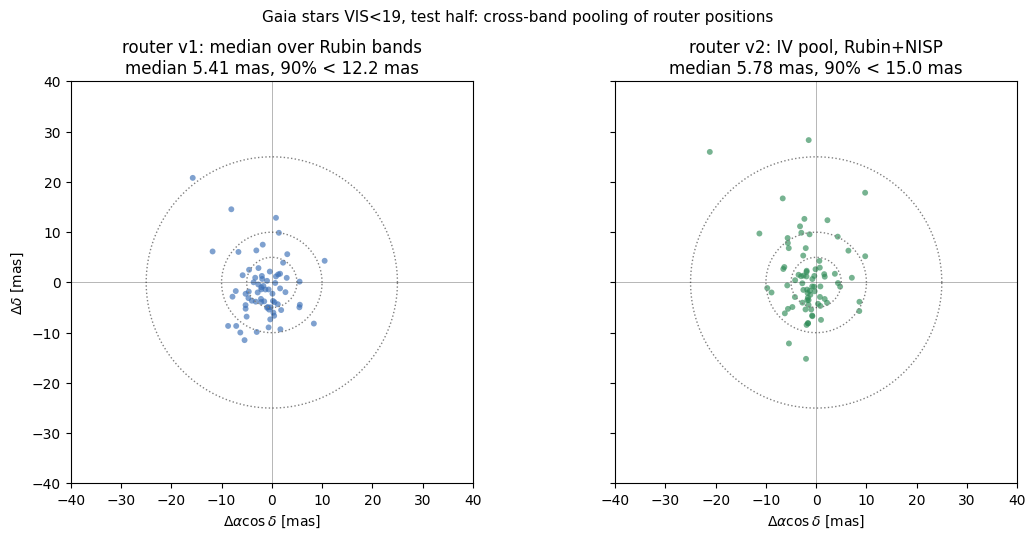

In [5]:
EPOCH=2024.83; REF=float(np.asarray(gaia['ref_epoch']).ravel()[0]); dt=EPOCH-REF
gra=np.asarray(gaia['ra'],float)+np.asarray(gaia['pmra'],float)*dt/3.6e6/cosd
gde=np.asarray(gaia['dec'],float)+np.asarray(gaia['pmdec'],float)*dt/3.6e6
s_r=-1.0

test['sig_comb']=np.sqrt((1-test.w2)**2*test.sig_cl**2 + test.w2**2*test.sig_h**2
                         + 2*test.w2*(1-test.w2)*test.rho*test.sig_cl*test.sig_h)

def gaia_frame(bands):
    gm=test[(test.src.map(pos.gaia_i)>=0)&(test.vmag<19.0)&test.band.isin(bands)].copy()
    gm['gi']=gm.src.map(pos.gaia_i)
    gm=gm[np.isfinite(gra[gm.gi])&np.isfinite(gde[gm.gi])]
    bx=(gm.ra.values-gra[gm.gi])*cosd*3.6e6; by=(gm.dec.values-gde[gm.gi])*3.6e6
    gm['bx']=bx; gm['by']=by                              # classical band position vs Gaia
    gm['c2xg']=bx-s_r*gm.rx.values+s_r*gm.c2x.values      # router position vs Gaia
    gm['c2yg']=by-s_r*gm.ry.values+s_r*gm.c2y.values
    gm['wp']=1.0/gm.sig_comb.clip(lower=0.5)**2
    return gm

def pool(gm, cols, how):
    if how=='median':
        return gm.groupby('src')[list(cols)].median()
    t=gm.copy()
    for c in cols:
        t[c]=t[c]*t.wp
    a=t.groupby('src')[list(cols)].sum()
    return a.div(gm.groupby('src')['wp'].sum(), axis=0)

def rad_stats(df, cx, cy):
    r=np.hypot(df[cx],df[cy])
    return float(np.median(r)), float(np.percentile(r,90)), len(df)

gm_r=gaia_frame(RUBIN)
gm_rn=gaia_frame(RUBIN+['nisp_Y','nisp_J','nisp_H'])
rows=[]
for name, gm_, cols, how in [
        ('classical, median over Rubin (nb24 view)',      gm_r,  ('bx','by'),     'median'),
        ('router,    median over Rubin (nb24 = 5.4)',     gm_r,  ('c2xg','c2yg'), 'median'),
        ('router,    IV pool over Rubin  (v2)',           gm_r,  ('c2xg','c2yg'), 'iv'),
        ('router,    IV pool Rubin+NISP  (v2)',           gm_rn, ('c2xg','c2yg'), 'iv'),
        ('classical, IV pool Rubin+NISP',                 gm_rn, ('bx','by'),     'iv'),
]:
    med,p90,n=rad_stats(pool(gm_, cols, how), *cols)
    rows.append((name,med,p90,n))
    print(f'{name:44s} median {med:5.2f} mas   90% {p90:5.1f}   N_src {n}')

per_v1=pool(gm_r,('c2xg','c2yg'),'median'); per_v2=pool(gm_rn,('c2xg','c2yg'),'iv')
fig,axes=plt.subplots(1,2,figsize=(11.5,5.4),sharex=True,sharey=True)
for ax,(per,cx,cy,title,col) in zip(axes,[(per_v1,'c2xg','c2yg','router v1: median over Rubin bands','#3b6fb6'),
                                          (per_v2,'c2xg','c2yg','router v2: IV pool, Rubin+NISP','#2e8b57')]):
    x,y=per[cx],per[cy]; r=np.hypot(x,y)
    ax.scatter(x,y,s=18,alpha=0.65,color=col,edgecolors='none')
    for rad in [5,10,25]:
        th=np.linspace(0,2*np.pi,200); ax.plot(rad*np.cos(th),rad*np.sin(th),ls=':',color='gray',lw=1)
    ax.axhline(0,color='k',lw=0.5,alpha=0.4); ax.axvline(0,color='k',lw=0.5,alpha=0.4)
    ax.set(xlim=(-40,40),ylim=(-40,40),aspect='equal',xlabel=r'$\Delta\alpha\cos\delta$ [mas]',
           title=f'{title}\nmedian {np.median(r):.2f} mas, 90% < {np.percentile(r,90):.1f} mas')
axes[0].set_ylabel(r'$\Delta\delta$ [mas]')
fig.suptitle(f'Gaia stars VIS<19, test half: cross-band pooling of router positions',fontsize=11)
plt.tight_layout(); fig.savefig(OUT/'nb27_gaia_pooling.png',dpi=140,bbox_inches='tight'); plt.show()

## The real-sky independence matrix

The injection test found inter-band error correlations of ~0.01. Real sky is where shared
systematics live (inter-instrument registration, the common anchor, the head pulling all
bands toward one canonical position). Per band, the classical-position error vs Gaia
(per-source, per-component); correlations across bands over the common sources. The mean
off-diagonal correlation $\bar\rho$ sets the pooling floor:
$\sigma^2_{\rm pool}\to\sigma^2(\frac{1-\bar\rho}{N}+\bar\rho)$.

classical band positions: mean off-diag rho = 0.43, median 0.17
router positions: mean off-diag rho = 0.66, median 0.55


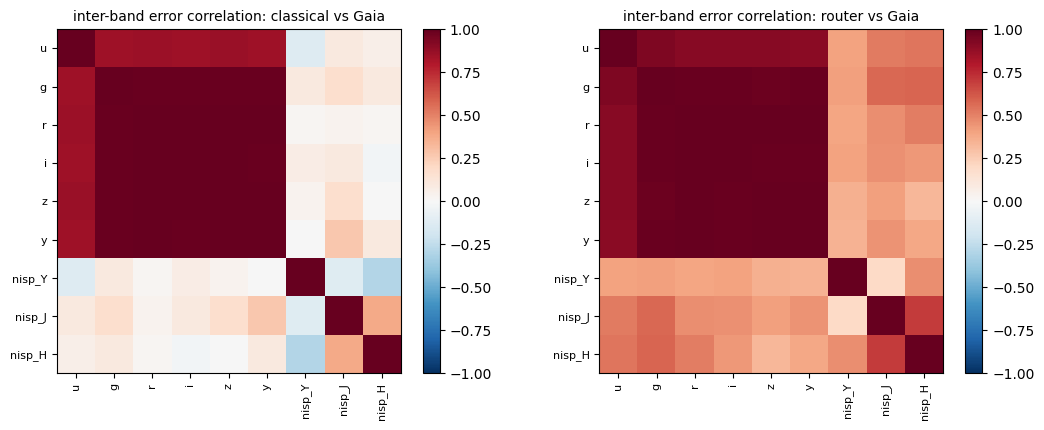

In [6]:
bset=RUBIN+['nisp_Y','nisp_J','nisp_H']
gmm=gaia_frame(bset)
piv_bx=gmm.pivot_table(index='src',columns='band',values='bx')
piv_by=gmm.pivot_table(index='src',columns='band',values='by')
piv_cx=gmm.pivot_table(index='src',columns='band',values='c2xg')
piv_cy=gmm.pivot_table(index='src',columns='band',values='c2yg')
def corrmat(px,py,order):
    cs=[]
    for p in (px,py):
        p=p[order]
        c=p.corr(min_periods=25).values
        cs.append(c)
    return np.nanmean(np.stack(cs),0)
order=[b for b in bset if b in piv_bx.columns]
C_cl=corrmat(piv_bx,piv_by,order)
C_rt=corrmat(piv_cx,piv_cy,order)
for name,C in [('classical band positions',C_cl),('router positions',C_rt)]:
    off=C[~np.eye(len(order),dtype=bool)]
    print(f'{name}: mean off-diag rho = {np.nanmean(off):.2f}, median {np.nanmedian(off):.2f}')
fig,axes=plt.subplots(1,2,figsize=(11,4.4))
for ax,(name,C) in zip(axes,[('classical vs Gaia',C_cl),('router vs Gaia',C_rt)]):
    im=ax.imshow(C,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order,rotation=90,fontsize=8)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order,fontsize=8)
    ax.set_title(f'inter-band error correlation: {name}',fontsize=10)
    plt.colorbar(im,ax=ax,fraction=0.046)
plt.tight_layout(); fig.savefig(OUT/'nb27_independence_matrix.png',dpi=140,bbox_inches='tight'); plt.show()

## Faint end — internal consistency (no external truth)

Below Gaia, split the bands into two disjoint sets, pool each half independently, and use
the half-vs-half distance as a scatter proxy (${\rm scale}/\sqrt2$ per pooled estimate,
under equal-information halves). This ranks median-pool vs IV-pool fairly even though the
head's shared component makes the absolute scale optimistic.

half-vs-half pooled-position scatter proxy (mas, per pooled estimate):
       S/N range      N  median pool   IV pool
      5-10         7857        10.34      8.42
     10-20         4199         4.94      4.28
     20-39         1092         3.15      2.57
     39-77          182         2.47      2.16
     77-152          70         3.73      3.24


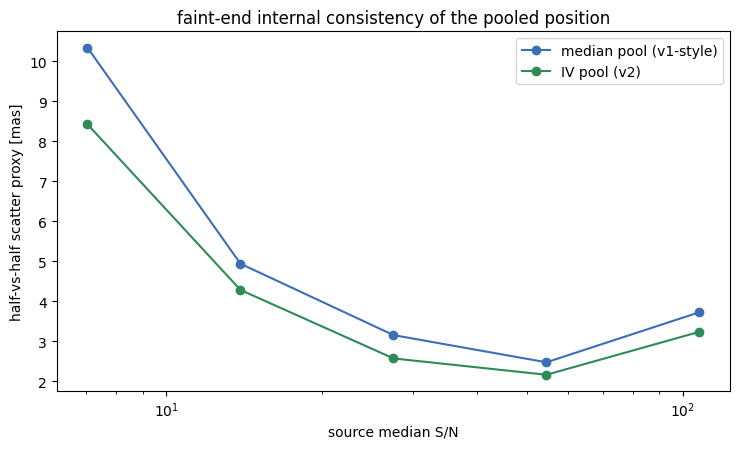

In [7]:
A={'g','i','nisp_Y','u'}; B={'r','z','y','nisp_J','nisp_H'}
tt=test.copy(); tt['wp']=1.0/tt.sig_comb.clip(lower=0.5)**2
tt['px']=-s_r*tt.rx+s_r*tt.c2x   # router correction relative to the (band-row) archive position
tt['py']=-s_r*tt.ry+s_r*tt.c2y
# absolute per-band router positions in a common frame: archive (ra,dec) + correction
tt['posx']=(tt.ra-tt.groupby('src').ra.transform('median'))*cosd*3.6e6+tt.px
tt['posy']=(tt.dec-tt.groupby('src').dec.transform('median'))*3.6e6+tt.py
snr_src=tt.groupby('src').snr.median()
res={}
for how in ['median','iv']:
    halves={}
    for tag,S in [('A',A),('B',B)]:
        g=tt[tt.band.isin(S)]
        if how=='median':
            halves[tag]=g.groupby('src')[['posx','posy']].median()
        else:
            gg=g.copy(); gg[['posx','posy']]=gg[['posx','posy']].mul(gg.wp,axis=0)
            halves[tag]=gg.groupby('src')[['posx','posy']].sum().div(g.groupby('src').wp.sum(),axis=0)
    j=halves['A'].join(halves['B'],lsuffix='_a',rsuffix='_b').dropna()
    dx=j.posx_a-j.posx_b; dy=j.posy_a-j.posy_b
    j['half_dist']=np.hypot(dx,dy)/np.sqrt(2)
    j['snr']=snr_src
    res[how]=j
print('half-vs-half pooled-position scatter proxy (mas, per pooled estimate):')
sb3=np.geomspace(5,300,7)
print(f'{"S/N range":>16s} {"N":>6s} {"median pool":>12s} {"IV pool":>9s}')
for lo,hi in zip(sb3[:-1],sb3[1:]):
    m={h:res[h][(res[h].snr>=lo)&(res[h].snr<hi)] for h in res}
    if len(m['median'])>50:
        print(f'{lo:7.0f}-{hi:<8.0f} {len(m["median"]):6d} {m["median"].half_dist.median():12.2f} '
              f'{m["iv"].half_dist.median():9.2f}')
fig,ax=plt.subplots(figsize=(7.5,4.6))
cen3=np.sqrt(sb3[1:]*sb3[:-1])
for how,col,lab in [('median','#3b6fb6','median pool (v1-style)'),('iv','#2e8b57','IV pool (v2)')]:
    y=[res[how][(res[how].snr>=lo)&(res[how].snr<hi)].half_dist.median() for lo,hi in zip(sb3[:-1],sb3[1:])]
    ax.plot(cen3,y,'o-',color=col,label=lab)
ax.set(xscale='log',xlabel='source median S/N',ylabel='half-vs-half scatter proxy [mas]',
       title='faint-end internal consistency of the pooled position')
ax.legend(); plt.tight_layout(); fig.savefig(OUT/'nb27_faint_internal.png',dpi=140,bbox_inches='tight'); plt.show()

## Verdict — the bright end is systematics-floored; v2 helps the faint end

**Bright stars (Gaia, VIS<19, test half, N=72):** IV pooling over Rubin gives 5.12 mas vs
5.41 for the nb24 median pool — a ~5% change, i.e. nothing. Adding NISP with statistical
weights makes it *worse* (5.78), because the weights ignore NISP's systematic component.
The reason is the independence matrix: on real sky the six Rubin bands' position errors vs
Gaia are correlated at $\rho\approx0.9$–$1.0$ — **they share one WCS per tile (one
`wcs_hdr` for the whole cube), so Rubin contributes ONE independent astrometric vote, not
six.** The router's head component correlates everything further (mean off-diag 0.66 vs
0.43 classical). The effective number of independent measurements per source is ~3 (Rubin,
VIS, NISP-ish), and the ~5 mas bright-star result is a shared inter-instrument systematic
— empirically confirming the SITCOMTN-159-scale floor. The injection-space 3.4 mas assumed
ten independent WCS-true bands; that regime does not exist at the bright end on real sky.

**Faint end (no external truth; half-vs-half band-split proxy):** here statistical noise
still dominates the systematics, so pooling has room. IV pooling beats median pooling
consistently: 10.3 → 8.4 mas at S/N 5–10, 4.9 → 4.3 at 10–20, 3.2 → 2.6 at 20–39 (~15–19%
better). The absolute scale is optimistic (the halves share the head's canonical pull),
but the ranking is fair: **v2's calibrated IV pooling is the better faint-end aggregation,
for free.**

**What this means for the program** (revised after re-reading the paper):
- Adopt IV pooling (with the $\sigma_{\rm comb}$ weights) as the catalog-level
  aggregation; expect ~15% faint-end improvement, no bright-end change. Do not include
  NISP without adding a per-band systematic floor term to the weights.
- **Head v2's value is at the faint end**, where errors are statistics-dominated and the
  multi-band information is real (nb26 gate 0: ×1.38 for S/N 3–10 sources, 14 → 10 mas).
  The bright-end injection target of 3.4 mas is not reachable on real sky, and the paper
  already concedes the bright end by design: bright Gaia stars are the population through
  which both surveys are registered, their classical positions "arrive essentially
  solved," and the router hands them back to classical centroiding.
- The correlation structure measured here is **the per-source covariance view of the
  paper's concordance field**: the dominant shared term the HGP decomposes (a ~7 mas
  common component, ~80% of the field variance, plus 1.5–3 mas per-band terms) is what
  appears in this notebook as large inter-band error correlations. The paper already maps
  it and shows that subtracting it re-centers the bright clouds from ~8 to ~1 mas within
  the mapped footprint (with the stated caveat that the field does not extrapolate off
  the footprint). This notebook adds the vs-Gaia view and the demonstration that this
  same structure is what caps cross-band pooling.
- The single shared Rubin astrometric solution is a property of the **delivered DP1
  coadds** (all bands on one tract/patch grid), not of our tile construction; the remedy
  is the direction the paper's discussion already names — pushing the representation
  toward native-sampling and single-exposure inputs, where the per-band astrometric
  signal survives.

**Caveats:** 72 Gaia stars (small); test half of ECDFS only; the correlation matrix mixes
tile-level and source-level systematics; NISP result uses statistical weights only.
